# 🧪 Comparing CNN & Vision Transformer Architectures on CIFAR-10 Dataset

## 📦 1. Python Dependencies

To run this notebook, make sure you have the following packages installed:

```bash
pip install torch torchvision matplotlib pandas timm
```
⚠️ If you're using Google Colab or a similar environment, most of these libraries are pre-installed.

## 🎯 2. Objective

To evaluate and compare the performance and efficiency of different convolutional neural network (CNN) and Vision Transformers (ViT) architectures on an image classification task using a subset of the CIFAR-10 dataset. You will measure:

* 🕒 Training time
* 🧠 Model accuracy
* 📉 Loss curves
* 🧮 Model size (# parameters)
* 🚀 Inference speed

You will use a selection of standard models from torchvision.models:

* ResNet18

* MobileNetV2

* EfficientNet_B0

* VGG11

* ViT base



## 📦 3. Import Dependencies

In [2]:
%pip install pandas timm

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Subset, random_split
import time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as colors

import timm # For ViT model
import pandas as pd

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


## 🗂️ 2. Load & Preprocess Data
* Use a subset of CIFAR-10 (e.g., 3–5 classes, 200 images per class) 
* Resize images to 224×224 to work with all pretrained models

In [3]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

# Load full CIFAR-10 training dataset
full_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)

# Restrict to 3 classes (e.g. classes 0,1,2) with 200 samples each for speed
selected_classes = [0, 1, 2]
indices = [i for i, (_, label) in enumerate(full_dataset) if label in selected_classes]

# Limit samples per class
class_counts = {c:0 for c in selected_classes}
limited_indices = []
for idx in indices:
    lbl = full_dataset[idx][1]
    if class_counts[lbl] < 200:
        limited_indices.append(idx)
        class_counts[lbl] += 1
    if all(count >= 200 for count in class_counts.values()):
        break

reduced_dataset = Subset(full_dataset, limited_indices)

# Split 60% train, 20% val, 20% test
total_len = len(reduced_dataset)
train_len = int(0.6 * total_len)
val_len = int(0.2 * total_len)
test_len = total_len - train_len - val_len

train_set, val_set, test_set = random_split(reduced_dataset, [train_len, val_len, test_len])

train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
val_loader = DataLoader(val_set, batch_size=32, shuffle=False)
test_loader = DataLoader(test_set, batch_size=32, shuffle=False)


Files already downloaded and verified


## 🏗️ 3. Define Architectures
For each model:
* Load pretrained weights
* Freeze feature layers
* Replace classifier head for the specific number of classes

In [4]:

def get_resnet18(device, num_classes):
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model.to(device)

def get_mobilenetv2(device, num_classes):
    model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
    model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
    return model.to(device)

def get_efficientnetb0(device, num_classes):
    model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
    model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
    return model.to(device)

def get_vgg11(device, num_classes):
    model = models.vgg11(weights=models.VGG11_Weights.DEFAULT)
    model.classifier[6] = nn.Linear(model.classifier[6].in_features, num_classes)
    return model.to(device)

def get_vit_base(device, num_classes):
    model = timm.create_model('vit_base_patch16_224', pretrained=True)
    model.head = nn.Linear(model.head.in_features, num_classes)
    return model.to(device)


models_dict = {
    'ResNet18': get_resnet18,
    'MobileNetV2': get_mobilenetv2,
    "EfficientNet_B0": get_efficientnetb0,
    'VGG11': get_vgg11,
    'ViT Base': get_vit_base,
}


## 🏋️‍♂️ 4. Train with Validation
For each model track:
* Average training time per epoch
* Final validation accuracy
* Number of parameters
* Average inference time on a batch

In [5]:
def train_with_validation(model, device, train_loader, val_loader, epochs=5, lr=1e-3):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)

    train_losses, val_losses = [], []
    time_per_epoch = 0


    for epoch in range(epochs):
        start_time = time.time()
        model.train()
        running_train_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_train_loss += loss.item()

        # 🔍 Validation
        model.eval()
        running_val_loss = 0.0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                val_loss = criterion(outputs, labels)
                running_val_loss += val_loss.item()

        avg_train_loss = running_train_loss / len(train_loader)
        avg_val_loss = running_val_loss / len(val_loader)
        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)
        end_time = time.time()

        print(f"📈 Epoch {epoch+1}/{epochs} - Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | {(end_time-start_time):4f} seconds ")
        time_per_epoch += end_time - start_time
    return train_losses, val_losses, time_per_epoch/epochs


## 🧮  5. Evaluation on Test Set

In [6]:
def evaluate_accuracy(model, device, loader):
    model.eval()
    correct = 0
    total = 0
    time_per_batch = 0
    batches = 0
    with torch.no_grad():
        for imgs, labels in loader:
            start_time = time.time()
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            _, preds = torch.max(outputs, 1)
            end_time = time.time()
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            time_per_batch += end_time - start_time
            batches += 1
            
    return correct / total, time_per_batch/batches

## ⚡ 6. Run Experiments & Collect Results

In [7]:
results = []
num_classes = len(selected_classes)
device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')

for name, model_fn in models_dict.items():
    print(f"--- Training {name} ---")
    model = model_fn(device, num_classes)
    train_losses, val_losses, time_per_epoch = train_with_validation(model, device, train_loader, val_loader, epochs=5)
    test_acc, time_per_batch = evaluate_accuracy(model, device, test_loader)
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad) / 1e6
    print(f"{name} test accuracy: {test_acc:.4f}, train time per epoch (s): {time_per_epoch:.4f}, params (M): {n_params:.2f}, inference time per batch (s): {time_per_batch:.4f} \n")
    results.append({
        'Model': name,
        'Train time per epoch (s)': time_per_epoch,
        'Test Accuracy': test_acc,
        'Inference time per batch (s)': time_per_batch,
        'Params (M)': n_params
    })


--- Training ResNet18 ---
📈 Epoch 1/5 - Train Loss: 0.6284 | Val Loss: 3.1535 | 24.729748 seconds 
📈 Epoch 2/5 - Train Loss: 0.2615 | Val Loss: 2.5971 | 25.974442 seconds 
📈 Epoch 3/5 - Train Loss: 0.2471 | Val Loss: 0.4631 | 25.416493 seconds 
📈 Epoch 4/5 - Train Loss: 0.1380 | Val Loss: 0.7127 | 24.694970 seconds 
📈 Epoch 5/5 - Train Loss: 0.0641 | Val Loss: 0.5943 | 25.146486 seconds 
ResNet18 test accuracy: 0.8250, train time per epoch (s): 25.1924, params (M): 11.18, inference time per batch (s): 0.5946 

--- Training MobileNetV2 ---


Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /home/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth
100%|██████████| 13.6M/13.6M [00:00<00:00, 17.8MB/s]


📈 Epoch 1/5 - Train Loss: 0.5641 | Val Loss: 1.0093 | 22.564578 seconds 
📈 Epoch 2/5 - Train Loss: 0.1181 | Val Loss: 0.8333 | 21.477134 seconds 
📈 Epoch 3/5 - Train Loss: 0.0682 | Val Loss: 0.3068 | 20.988857 seconds 
📈 Epoch 4/5 - Train Loss: 0.1621 | Val Loss: 0.2392 | 24.049992 seconds 
📈 Epoch 5/5 - Train Loss: 0.2395 | Val Loss: 0.3972 | 24.554619 seconds 
MobileNetV2 test accuracy: 0.8667, train time per epoch (s): 22.7270, params (M): 2.23, inference time per batch (s): 0.4096 

--- Training EfficientNet_B0 ---


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /home/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth
100%|██████████| 20.5M/20.5M [00:02<00:00, 7.32MB/s]


📈 Epoch 1/5 - Train Loss: 0.6130 | Val Loss: 0.9625 | 32.672193 seconds 
📈 Epoch 2/5 - Train Loss: 0.1278 | Val Loss: 0.7125 | 32.581995 seconds 
📈 Epoch 3/5 - Train Loss: 0.1245 | Val Loss: 0.5870 | 32.306467 seconds 
📈 Epoch 4/5 - Train Loss: 0.0837 | Val Loss: 0.3589 | 31.729389 seconds 
📈 Epoch 5/5 - Train Loss: 0.0463 | Val Loss: 0.2436 | 35.276783 seconds 
EfficientNet_B0 test accuracy: 0.9417, train time per epoch (s): 32.9134, params (M): 4.01, inference time per batch (s): 0.5548 

--- Training VGG11 ---


Downloading: "https://download.pytorch.org/models/vgg11-8a719046.pth" to /home/torch/hub/checkpoints/vgg11-8a719046.pth
100%|██████████| 507M/507M [00:24<00:00, 22.1MB/s] 


📈 Epoch 1/5 - Train Loss: 1.5227 | Val Loss: 1.1037 | 89.266928 seconds 
📈 Epoch 2/5 - Train Loss: 1.1054 | Val Loss: 1.0194 | 97.198454 seconds 
📈 Epoch 3/5 - Train Loss: 1.0574 | Val Loss: 0.8878 | 90.279687 seconds 
📈 Epoch 4/5 - Train Loss: 0.8847 | Val Loss: 0.8930 | 97.847764 seconds 
📈 Epoch 5/5 - Train Loss: 0.7689 | Val Loss: 0.8914 | 93.135068 seconds 
VGG11 test accuracy: 0.7500, train time per epoch (s): 93.5456, params (M): 128.78, inference time per batch (s): 2.5192 

--- Training ViT Base ---


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

📈 Epoch 1/5 - Train Loss: 5.3550 | Val Loss: 1.5960 | 234.451095 seconds 
📈 Epoch 2/5 - Train Loss: 1.3859 | Val Loss: 1.1220 | 234.684058 seconds 
📈 Epoch 3/5 - Train Loss: 1.2543 | Val Loss: 1.1042 | 240.793893 seconds 
📈 Epoch 4/5 - Train Loss: 1.1606 | Val Loss: 1.1733 | 243.278662 seconds 
📈 Epoch 5/5 - Train Loss: 1.1202 | Val Loss: 1.1482 | 223.711371 seconds 
ViT Base test accuracy: 0.3167, train time per epoch (s): 235.3838, params (M): 85.80, inference time per batch (s): 5.7015 



## 5. 📊 Log and Compare Results

Use a pandas DataFrame to compare the values:

             Model  Train time per epoch (s)  Test Accuracy  \
0         ResNet18                 25.192428       0.825000   
1      MobileNetV2                 22.727036       0.866667   
2  EfficientNet_B0                 32.913365       0.941667   
3            VGG11                 93.545580       0.750000   
4         ViT Base                235.383816       0.316667   

   Inference time per batch (s)  Params (M)  
0                      0.594576   11.178051  
1                      0.409593    2.227715  
2                      0.554770    4.011391  
3                      2.519173  128.778627  
4                      5.701476   85.800963  


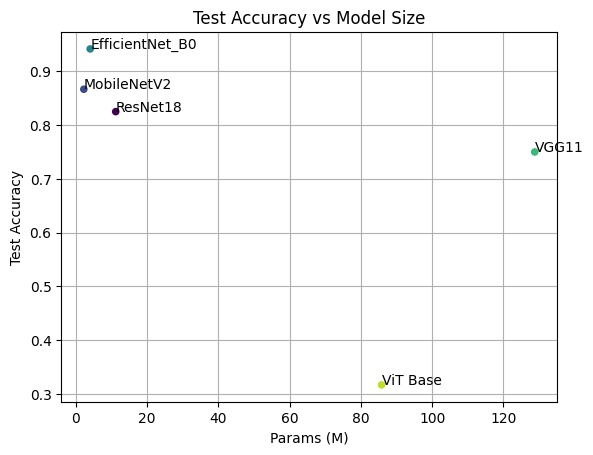

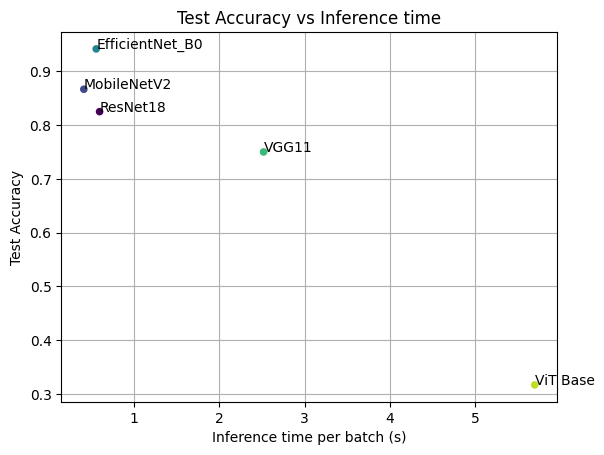

In [9]:
df = pd.DataFrame(results)
print(df)

colormap = cm.viridis
colorlist = [colors.rgb2hex(colormap(i)) for i in np.linspace(0, 0.9, len(df['Model']))]

ax = df.plot(x='Params (M)', y='Test Accuracy', kind='scatter', c=colorlist, title='Test Accuracy vs Model Size')

for idx, row in df.iterrows():
    ax.annotate(row['Model'], (row['Params (M)'], row['Test Accuracy']))
plt.grid(True)
plt.show()

ax = df.plot(x='Inference time per batch (s)', y='Test Accuracy', kind='scatter', c=colorlist, title='Test Accuracy vs Inference time')
for idx, row in df.iterrows():
    ax.annotate(row['Model'], (row['Inference time per batch (s)'], row['Test Accuracy']))

plt.grid(True)
plt.show()

## 6. 🤔 Discussion & Questions

1. ✅ Which model had the **best accuracy vs speed trade-off**?

2. 🧠 How does **model size** impact training time and accuracy?

3. 💡 What architecture would you recommend for:

   * Edge devices (low power)?

   * High-performance cloud inference?
  
   * 
  
4. Mismo dataset de antes. ViT no sobrepasan las ResNet para conjuntos perqueños de datos. 